In [1]:
import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.transforms import functional as TF
from tqdm.notebook import tqdm 

In [2]:
import os
import shutil
import random
import torch
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF


# Paths for Kaggle input and output
INPUT_PATH = '/kaggle/input/mvtec-ad/grid'
OUTPUT_PATH = '/kaggle/working/processed_data'


# Helper function to create directories
def create_directories():
    if os.path.exists(OUTPUT_PATH):
        shutil.rmtree(OUTPUT_PATH)
    
    os.makedirs(os.path.join(OUTPUT_PATH, 'train', 'defective'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'train', 'non_defective'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'val', 'defective'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'val', 'non_defective'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'test', 'defective'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_PATH, 'test', 'non_defective'), exist_ok=True)
    print(f"Directory structure created at {OUTPUT_PATH}")


# Collect defective and non-defective images
def collect_images():
    defect_types = ['bent', 'broken', 'glue', 'metal_contamination', 'thread']
    defective_images, non_defective_images = [], []
    
    # Collect defective images
    for defect in defect_types:
        defect_path = os.path.join(INPUT_PATH, 'test', defect)
        if os.path.exists(defect_path):
            defective_images.extend([os.path.join(defect_path, img) for img in os.listdir(defect_path) if img.endswith(('.png', '.jpg', '.jpeg'))])
    
    # Collect non-defective images
    for folder in ['test/good', 'train/good']:
        good_path = os.path.join(INPUT_PATH, folder)
        if os.path.exists(good_path):
            non_defective_images.extend([os.path.join(good_path, img) for img in os.listdir(good_path) if img.endswith(('.png', '.jpg', '.jpeg'))])
    
    return defective_images, non_defective_images


# Split and copy data to respective directories
def split_and_copy_data(image_list, label):
    # Adjust split ratios to get more test images
    # Using 50% for test, 40% for train, 10% for validation
    train_val, test = train_test_split(image_list, test_size=0.3, random_state=42)
    train, val = train_test_split(train_val, test_size=0.2, random_state=42)
    
    splits = {'train': train, 'val': val, 'test': test}
    images_per_split = {'train': 0, 'val': 0, 'test': 0}
    
    for split_name, split_files in splits.items():
        dest_dir = os.path.join(OUTPUT_PATH, split_name, label)
        
        for i, img_path in enumerate(split_files):
            img = Image.open(img_path).convert('RGB')
            
            if label == 'defective':
                # More augmentations for test set
                if split_name == 'test':
                    augmentations = augment_image(img, num_augmentations=8)  # 8 augmentations for test
                    for aug_idx, aug_img in enumerate(augmentations):
                        aug_img.save(os.path.join(dest_dir, f"{i:03d}_aug_{aug_idx + 1}.png"))
                    img.save(os.path.join(dest_dir, f"{i:03d}_original.png"))
                    images_per_split[split_name] += 9  # original + 8 augmented
                
                # Regular augmentations for train
                elif split_name == 'train':
                    augmentations = augment_image(img, num_augmentations=4)
                    for aug_idx, aug_img in enumerate(augmentations):
                        aug_img.save(os.path.join(dest_dir, f"{i:03d}_aug_{aug_idx + 1}.png"))
                    img.save(os.path.join(dest_dir, f"{i:03d}_original.png"))
                    images_per_split[split_name] += 5  # original + 4 augmented
                
                # Minimal augmentation for validation
                else:
                    img.save(os.path.join(dest_dir, f"{i:03d}_original.png"))
                    images_per_split[split_name] += 1
            else:
                # For non-defective images, just copy without augmentation
                img.save(os.path.join(dest_dir, f"{i:03d}.png"))
                images_per_split[split_name] += 1
    
    print(f"\nImages created for {label}:")
    for split, count in images_per_split.items():
        print(f"{split}: {count}")
    
    return sum(images_per_split.values())

def augment_image(img, num_augmentations=4):
    """Enhanced augmentation with more diverse transformations"""
    augmentations = [
        # Geometric transformations
        transforms.RandomRotation(degrees=30),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.RandomPerspective(distortion_scale=0.2, p=1.0),
        
        # Color transformations
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        
        # Blur and noise
        transforms.GaussianBlur(kernel_size=3),
        transforms.RandomAdjustSharpness(sharpness_factor=2),
        
        # Cropping and resizing
        transforms.RandomResizedCrop(
            size=img.size, 
            scale=(0.8, 1.0), 
            ratio=(0.9, 1.1)
        )
    ]
    
    aug_images = []
    for _ in range(num_augmentations):
        # Apply 3-4 random augmentations for each image
        selected_augments = random.sample(augmentations, random.randint(3, 4))
        transform = transforms.Compose(selected_augments)
        aug_images.append(transform(img))
    
    return aug_images

def verify_dataset_sizes():
    """Function to verify the size of each dataset split"""
    for split in ['train', 'val', 'test']:
        for class_name in ['defective', 'non_defective']:
            dir_path = os.path.join(OUTPUT_PATH, split, class_name)
            files = [f for f in os.listdir(dir_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
            print(f"\n{split}/{class_name} contains {len(files)} images")
            if split == 'test' and class_name == 'defective':
                originals = len([f for f in files if 'original' in f])
                augmented = len([f for f in files if 'aug' in f])
                print(f"Original images: {originals}")
                print(f"Augmented images: {augmented}")

# Verify the directory contents
def verify_directory_contents():
    for split in ['train', 'val', 'test']:
        for class_name in ['defective', 'non_defective']:
            dir_path = os.path.join(OUTPUT_PATH, split, class_name)
            files = [f for f in os.listdir(dir_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
            print(f"\n{split}/{class_name} directory contains {len(files)} images")
            if split == 'train' and class_name == 'defective':
                print("First 5 defective training images:")
                for f in sorted(files)[:5]:
                    print(f"- {f}")


# Dataset class for loading images
class GridDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images, self.labels = [], []
        for label, class_name in enumerate(['non_defective', 'defective']):
            class_dir = os.path.join(data_dir, class_name)
            class_images = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
            self.images.extend(class_images)
            self.labels.extend([label] * len(class_images))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


# Setup data loaders with transformations
def setup_data_loaders(batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    train_dataset = GridDataset(os.path.join(OUTPUT_PATH, 'train'), transform)
    val_dataset = GridDataset(os.path.join(OUTPUT_PATH, 'val'), transform)
    test_dataset = GridDataset(os.path.join(OUTPUT_PATH, 'test'), transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


# Weighted random sampler to handle class imbalance
def create_balanced_sampler(dataset):
    labels = [label for _, label in dataset]
    class_counts = torch.bincount(torch.tensor(labels))
    class_weights = len(labels) / (len(class_counts) * class_counts.float())
    sample_weights = [class_weights[label] for label in labels]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(dataset), replacement=True)


# Setup balanced data loaders
def setup_balanced_data_loaders(batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    train_dataset = GridDataset(os.path.join(OUTPUT_PATH, 'train'), transform)
    val_dataset = GridDataset(os.path.join(OUTPUT_PATH, 'val'), transform)
    test_dataset = GridDataset(os.path.join(OUTPUT_PATH, 'test'), transform)
    
    train_sampler = create_balanced_sampler(train_dataset)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


# Main function to prepare data and create loaders
def main():
    print("Starting data preparation...")
    
    create_directories()
    defective_images, non_defective_images = collect_images()
    
    print(f"\nTotal images collected:")
    print(f"Defective: {len(defective_images)}")
    print(f"Non-defective: {len(non_defective_images)}")
    
    total_defective = split_and_copy_data(defective_images, 'defective')
    total_non_defective = split_and_copy_data(non_defective_images, 'non_defective')
    
    # Verify final dataset sizes
    verify_dataset_sizes()
    
    train_loader, val_loader, test_loader = setup_balanced_data_loaders()
    
    print("\nData preparation completed!")
    return train_loader, val_loader, test_loader


if __name__ == "__main__":
    train_loader, val_loader, test_loader = main()


Starting data preparation...
Directory structure created at /kaggle/working/processed_data

Total images collected:
Defective: 57
Non-defective: 285

Images created for defective:
train: 155
val: 8
test: 162

Images created for non_defective:
train: 159
val: 40
test: 86

train/defective contains 155 images

train/non_defective contains 159 images

val/defective contains 8 images

val/non_defective contains 40 images

test/defective contains 162 images
Original images: 18
Augmented images: 144

test/non_defective contains 86 images

Data preparation completed!


In [3]:
class DefectClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet50(weights='IMAGENET1K_V2')  
        for param in self.model.parameters():  
            param.requires_grad = True
        self.model.fc = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )
    
    def forward(self, x):
        return self.model(x)


In [4]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    predictions, true_labels = [], []
    
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        predictions.extend(outputs.argmax(dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
    
    return running_loss / len(train_loader), predictions, true_labels

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    predictions, true_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            predictions.extend(outputs.argmax(dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    return running_loss / len(val_loader), predictions, true_labels

def calculate_metrics(true_labels, predictions):
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average='binary', zero_division=0
    )
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def plot_metrics(train_metrics, val_metrics):
    epochs = range(1, len(train_metrics['accuracy']) + 1)
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    
    plt.figure(figsize=(15, 10))
    for i, metric in enumerate(metrics, 1):
        plt.subplot(2, 2, i)
        plt.plot(epochs, train_metrics[metric], 'b-', label=f'Training {metric}')
        plt.plot(epochs, val_metrics[metric], 'r-', label=f'Validation {metric}')
        plt.title(f'{metric.capitalize()} vs. Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


In [5]:
def train_model(train_loader, val_loader, num_epochs=20):  # Changed from 10 to 20
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = DefectClassifier().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0001)  # Changed from Adam to AdamW
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
    
    best_val_f1 = 0.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_metrics': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
        'val_metrics': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # Training
        train_loss, train_preds, train_labels = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        train_metrics = calculate_metrics(train_labels, train_preds)
        
        # Validation
        val_loss, val_preds, val_labels = validate(
            model, val_loader, criterion, device
        )
        val_metrics = calculate_metrics(val_labels, val_preds)

        # After validation metrics are calculated
        scheduler.step(val_loss)  
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for metric in train_metrics:
            history['train_metrics'][metric].append(train_metrics[metric])
            history['val_metrics'][metric].append(val_metrics[metric])
        
        # Print metrics
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Training Metrics:", train_metrics)
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation Metrics:", val_metrics)
        
        # Save best model
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
            print("New best model saved!")
        
        # Plot confusion matrix every few epochs
        if (epoch + 1) % 5 == 0:
            plot_confusion_matrix(val_labels, val_preds)
    
    # Plot training history
    plot_metrics(history['train_metrics'], history['val_metrics'])
    return model, history
def test_time_augment(model, img, device, num_augments=5):
    model.eval()
    augmentations = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    predictions = []
    # Original image
    with torch.no_grad():
        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
        predictions.append(model(img_tensor))
        
    # Augmented versions
    for _ in range(num_augments):
        with torch.no_grad():
            aug_tensor = augmentations(img).unsqueeze(0).to(device)
            predictions.append(model(aug_tensor))
    
    # Average predictions
    return torch.stack(predictions).mean(0)

def evaluate_defective_images(model, test_dir, device):
    model.eval()
    defective_dir = os.path.join(test_dir, 'defective')
    results = []
    
    for img_name in os.listdir(defective_dir):
        img_path = os.path.join(defective_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        
        # Get prediction with test-time augmentation
        pred = test_time_augment(model, img, device)
        prob = torch.softmax(pred, dim=1)[0][1].item()  # Probability of defective class
        
        results.append({
            'image': img_name,
            'defect_probability': prob,
            'prediction': 'Defective' if prob > 0.5 else 'Non-Defective'
        })
    
    return results


In [6]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

def visualize_predictions(model, test_dir, device, num_images=10):
    model.eval()
    defective_dir = os.path.join(test_dir, 'defective')
    
    # Get all defective images
    image_files = [f for f in os.listdir(defective_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    # Select a subset of images
    selected_files = image_files[:num_images]
    
    # Create a grid of images
    fig = plt.figure(figsize=(20, 4))
    for idx, img_name in enumerate(selected_files, 1):
        img_path = os.path.join(defective_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        
        # Get prediction
        pred = test_time_augment(model, img, device)
        prob = torch.softmax(pred, dim=1)[0][1].item()
        
        # Add subplot
        plt.subplot(2, 5, idx)
        plt.imshow(img)
        plt.title(f'Prob: {prob:.2f}\n{"Defective" if prob > 0.5 else "Non-Defective"}', 
                 color='green' if prob > 0.5 else 'red')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Function to visualize specific images with heatmaps
def visualize_with_heatmap(model, img_path, device):
    # Load and preprocess image
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # Get model prediction
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)[0][1].item()
    
    # Create visualization
    plt.figure(figsize=(12, 4))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')
    
    # Add prediction text
    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, 
             f'Prediction: {"Defective" if prob > 0.5 else "Non-Defective"}\nConfidence: {prob:.2%}',
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=12,
             color='green' if prob > 0.5 else 'red')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Directory structure created at /kaggle/working/processed_data

Images created for defective:
train: 155
val: 8
test: 162

Images created for non_defective:
train: 159
val: 40
test: 86
Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]



Epoch 1/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.5490
Training Metrics: {'accuracy': 0.7229299363057324, 'precision': 0.6666666666666666, 'recall': 0.7916666666666666, 'f1': 0.7238095238095237}
Validation Loss: 0.6639
Validation Metrics: {'accuracy': 0.6875, 'precision': 0.18181818181818182, 'recall': 0.25, 'f1': 0.2105263157894737}

Epoch 5/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.4490
Training Metrics: {'accuracy': 0.8248407643312102, 'precision': 0.9067796610169492, 'recall': 0.7086092715231788, 'f1': 0.7955390334572491}
Validation Loss: 0.5884
Validation Metrics: {'accuracy': 0.8333333333333334, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


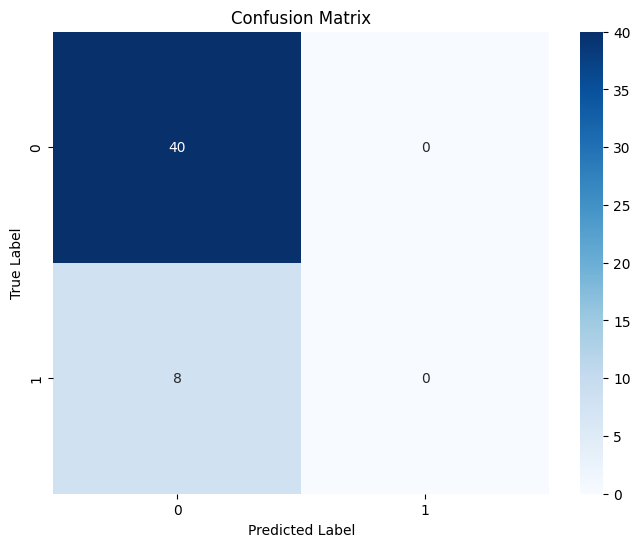


Epoch 6/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.3631
Training Metrics: {'accuracy': 0.8630573248407644, 'precision': 0.9112903225806451, 'recall': 0.7793103448275862, 'f1': 0.8401486988847584}
Validation Loss: 0.5666
Validation Metrics: {'accuracy': 0.8333333333333334, 'precision': 0.5, 'recall': 0.125, 'f1': 0.2}

Epoch 7/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.2063
Training Metrics: {'accuracy': 0.9171974522292994, 'precision': 0.9640287769784173, 'recall': 0.864516129032258, 'f1': 0.91156462585034}
Validation Loss: 0.3606
Validation Metrics: {'accuracy': 0.8333333333333334, 'precision': 0.5, 'recall': 0.875, 'f1': 0.6363636363636364}

Epoch 10/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.2137
Training Metrics: {'accuracy': 0.9171974522292994, 'precision': 0.9300699300699301, 'recall': 0.8926174496644296, 'f1': 0.910958904109589}
Validation Loss: 0.1762
Validation Metrics: {'accuracy': 0.9375, 'precision': 0.7777777777777778, 'recall': 0.875, 'f1': 0.823529411764706}
New best model saved!


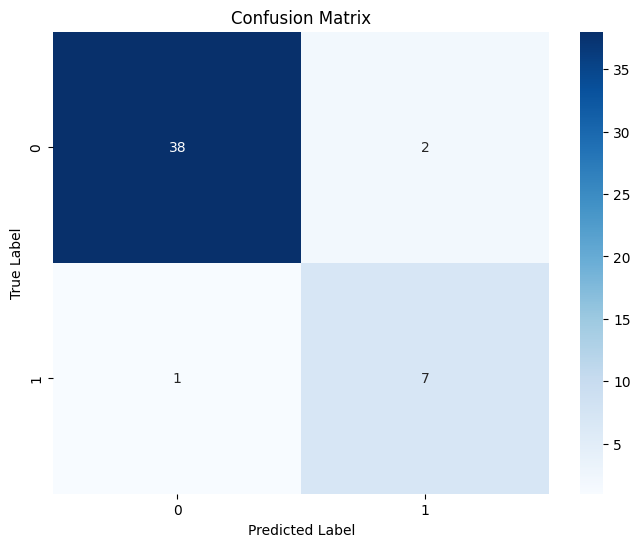


Epoch 11/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.1951
Training Metrics: {'accuracy': 0.9426751592356688, 'precision': 0.9859154929577465, 'recall': 0.8974358974358975, 'f1': 0.9395973154362417}
Validation Loss: 0.2222
Validation Metrics: {'accuracy': 0.9375, 'precision': 1.0, 'recall': 0.625, 'f1': 0.7692307692307693}

Epoch 12/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.1166
Training Metrics: {'accuracy': 0.9522292993630573, 'precision': 0.9931506849315068, 'recall': 0.9119496855345912, 'f1': 0.9508196721311475}
Validation Loss: 0.4316
Validation Metrics: {'accuracy': 0.9375, 'precision': 1.0, 'recall': 0.625, 'f1': 0.7692307692307693}

Epoch 15/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.1279
Training Metrics: {'accuracy': 0.9617834394904459, 'precision': 0.971830985915493, 'recall': 0.9452054794520548, 'f1': 0.9583333333333334}
Validation Loss: 0.0242
Validation Metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
New best model saved!


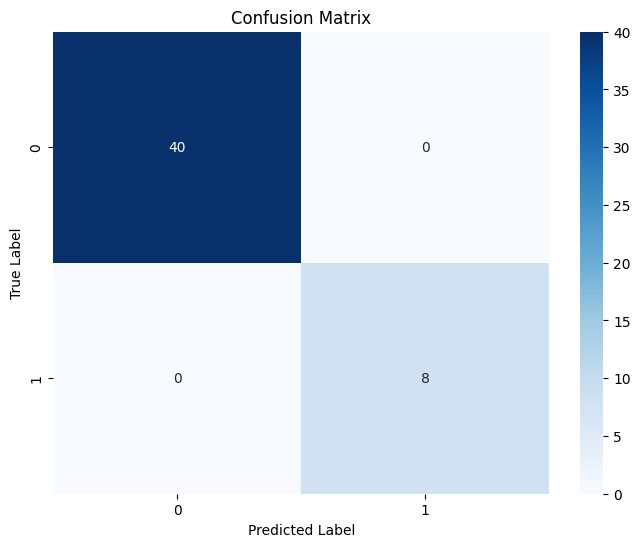


Epoch 16/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.1196
Training Metrics: {'accuracy': 0.9554140127388535, 'precision': 0.9781021897810219, 'recall': 0.9241379310344827, 'f1': 0.9503546099290779}
Validation Loss: 0.3585
Validation Metrics: {'accuracy': 0.9583333333333334, 'precision': 0.875, 'recall': 0.875, 'f1': 0.875}

Epoch 17/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.1318
Training Metrics: {'accuracy': 0.9554140127388535, 'precision': 1.0, 'recall': 0.9130434782608695, 'f1': 0.9545454545454545}
Validation Loss: 0.1547
Validation Metrics: {'accuracy': 0.9791666666666666, 'precision': 1.0, 'recall': 0.875, 'f1': 0.9333333333333333}

Epoch 20/20


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Training Loss: 0.1393
Training Metrics: {'accuracy': 0.9522292993630573, 'precision': 1.0, 'recall': 0.9090909090909091, 'f1': 0.9523809523809523}
Validation Loss: 0.1273
Validation Metrics: {'accuracy': 0.9583333333333334, 'precision': 1.0, 'recall': 0.75, 'f1': 0.8571428571428571}


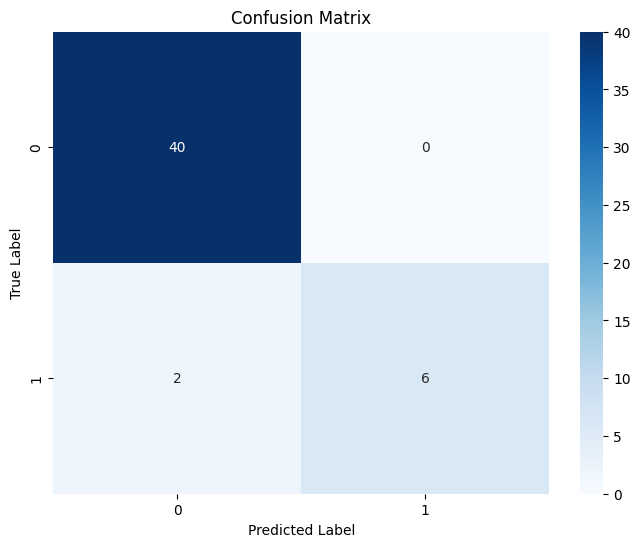

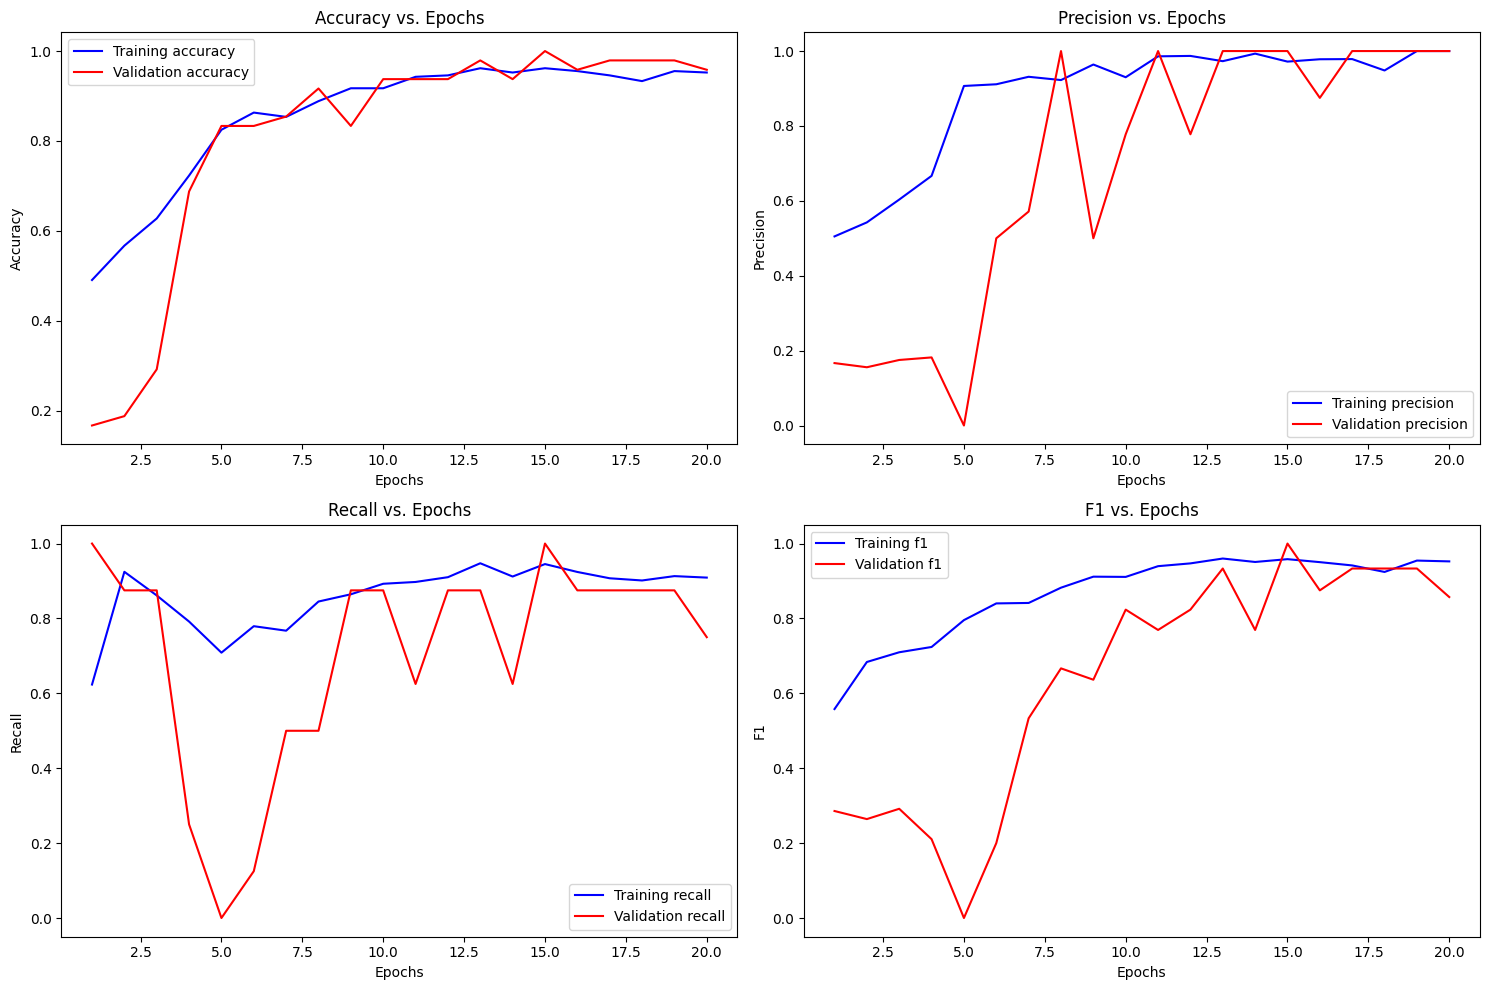

<ipython-input-7-79bef7d6354b>:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))



Detailed Defective Image Analysis:
Image: 003_aug_5.png
Defect Probability: 0.695
Prediction: Defective

Image: 003_aug_6.png
Defect Probability: 0.710
Prediction: Defective

Image: 001_original.png
Defect Probability: 0.603
Prediction: Defective

Image: 016_aug_4.png
Defect Probability: 0.666
Prediction: Defective

Image: 014_aug_1.png
Defect Probability: 0.793
Prediction: Defective

Image: 004_aug_1.png
Defect Probability: 0.757
Prediction: Defective

Image: 001_aug_4.png
Defect Probability: 0.666
Prediction: Defective

Image: 008_aug_5.png
Defect Probability: 0.776
Prediction: Defective

Image: 015_aug_3.png
Defect Probability: 0.515
Prediction: Defective

Image: 009_aug_8.png
Defect Probability: 0.557
Prediction: Defective

Image: 013_aug_7.png
Defect Probability: 0.660
Prediction: Defective

Image: 001_aug_1.png
Defect Probability: 0.713
Prediction: Defective

Image: 014_original.png
Defect Probability: 0.554
Prediction: Defective

Image: 009_aug_7.png
Defect Probability: 0.601
P

Validation:   0%|          | 0/8 [00:00<?, ?it/s]


Test Set Metrics: {'accuracy': 0.9637096774193549, 'precision': 0.9872611464968153, 'recall': 0.9567901234567902, 'f1': 0.9717868338557994}

Visualizing Predictions...


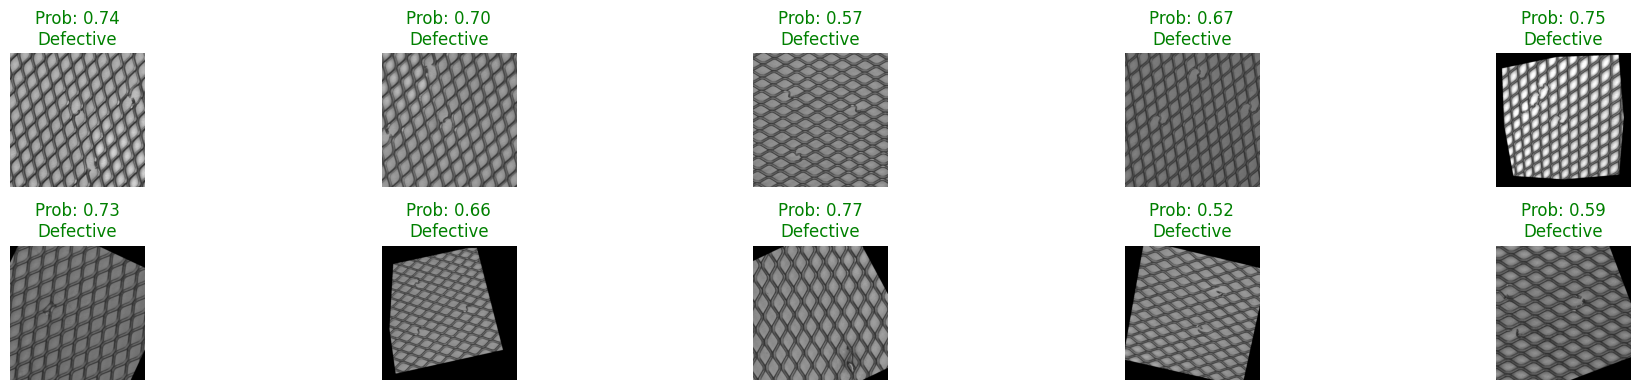


Analyzing image: 000_aug_1.png


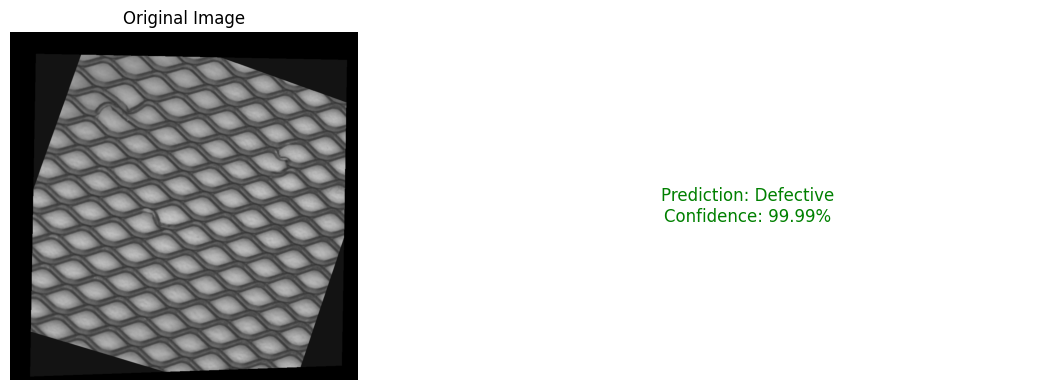


Analyzing image: 000_aug_2.png


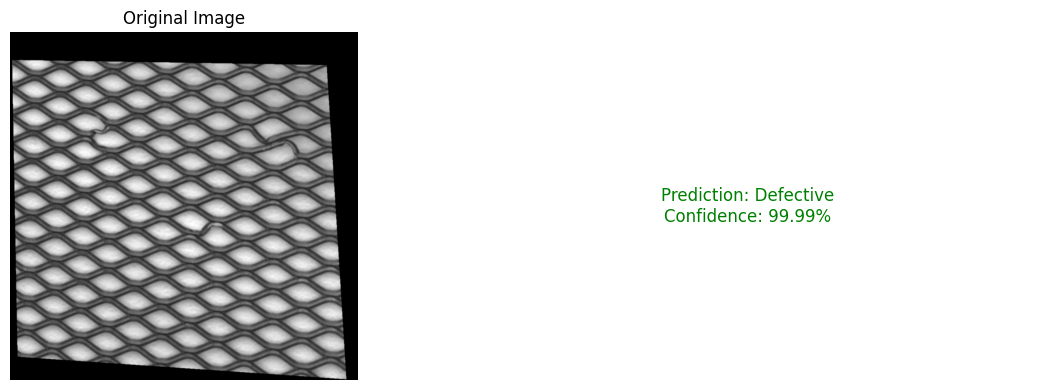


Analyzing image: 000_aug_3.png


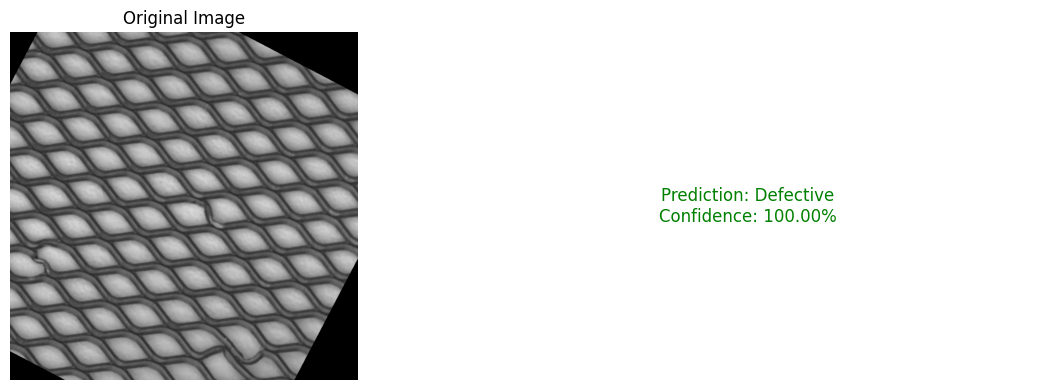

In [7]:
if __name__ == "__main__":
    # Create directories and prepare data
    create_directories()
    defective_images, non_defective_images = collect_images()
    
    # Split and process data
    total_defective = split_and_copy_data(defective_images, 'defective')
    total_non_defective = split_and_copy_data(non_defective_images, 'non_defective')
    
    # Set up data loaders
    train_loader, val_loader, test_loader = setup_balanced_data_loaders()
    
    # Train model
    model, history = train_model(train_loader, val_loader)
    
    # Load best model and evaluate
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    best_model = DefectClassifier().to(device)
    best_model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))

    # Add this to your main execution after loading the best model:
    test_dir = os.path.join(OUTPUT_PATH, 'test')
    defect_results = evaluate_defective_images(best_model, test_dir, device)

    # Print detailed results
    print("\nDetailed Defective Image Analysis:")
    for result in defect_results:
        print(f"Image: {result['image']}")
        print(f"Defect Probability: {result['defect_probability']:.3f}")
        print(f"Prediction: {result['prediction']}\n")
    
    # Calculate success rate on defective images
    success_rate = sum(1 for r in defect_results if r['prediction'] == 'Defective') / len(defect_results)
    print(f"Success rate on defective images: {success_rate:.2%}")
    
    # Run evaluations
    test_loss, test_preds, test_labels = validate(best_model, test_loader, nn.CrossEntropyLoss(), device)
    test_metrics = calculate_metrics(test_labels, test_preds)
    print("\nTest Set Metrics:", test_metrics)
    
    # Add the visualization code right here
    print("\nVisualizing Predictions...")
    test_dir = os.path.join(OUTPUT_PATH, 'test')
    visualize_predictions(best_model, test_dir, device)

    # Visualize a few specific images in detail
    defective_dir = os.path.join(test_dir, 'defective')
    for img_name in sorted(os.listdir(defective_dir))[:3]:  # Show first 3 images
        img_path = os.path.join(defective_dir, img_name)
        print(f"\nAnalyzing image: {img_name}")
        visualize_with_heatmap(best_model, img_path, device)